In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

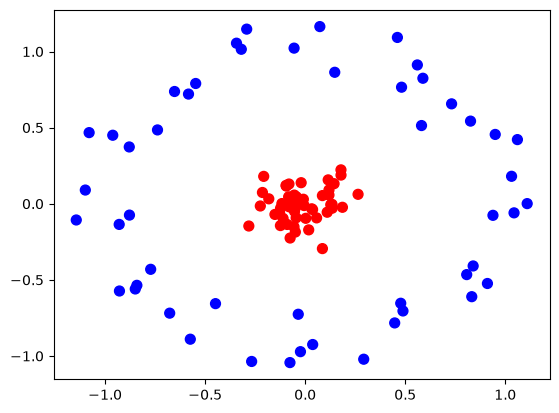

In [9]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [11]:
classifier = SVC(kernel="linear") # using linear svm 
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

In [13]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_8303/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


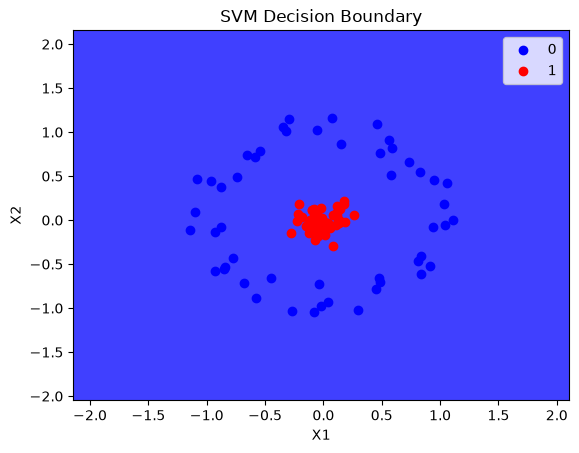

In [14]:
plot_decision_boundary(X, y, classifier)

In [ ]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))  # radial basis function
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

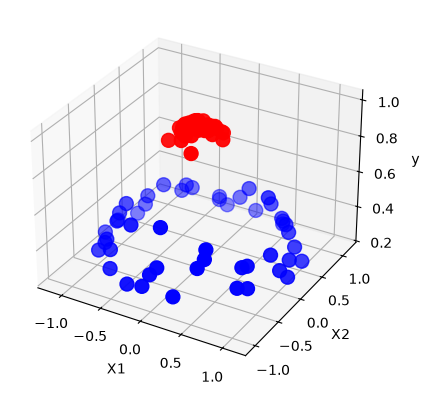

In [16]:
plot_3d_plot(X,y)

In [17]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [18]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_8303/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


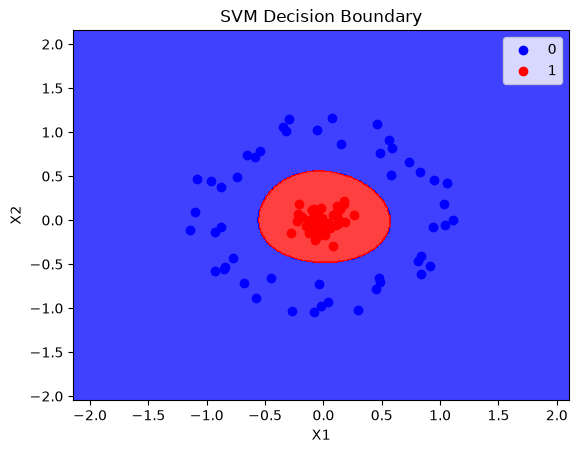

In [19]:
plot_decision_boundary(X, y, rbf_classifier)

In [27]:
poly_classifier = SVC(kernel="poly",degree=3) # 3 is default too
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [28]:
accuracy_score(y_test, y_pred)

0.4

/tmp/ipykernel_8303/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


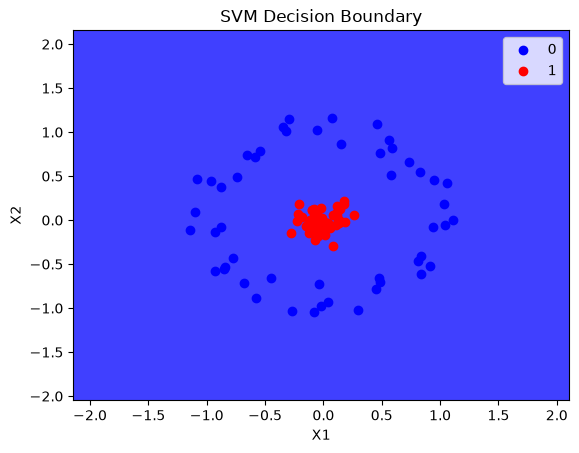

In [29]:
plot_decision_boundary(X, y, poly_classifier)

In [30]:
poly_classifier2 = SVC(kernel="poly",degree=2)
poly_classifier2.fit(X_train, y_train)
y_pred = poly_classifier2.predict(X_test)

In [31]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_8303/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


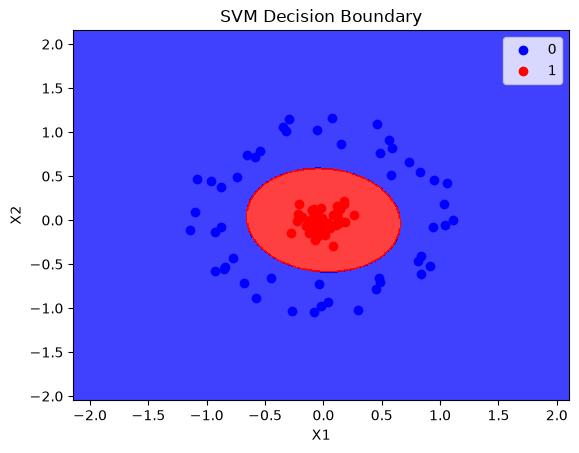

In [32]:
plot_decision_boundary(X, y, poly_classifier2)

In [23]:
X

array([[-4.91764708e-02, -1.85657808e-01],
       [ 1.10939284e+00,  9.62413337e-04],
       [ 1.76462971e-02, -1.71468067e-01],
       [ 2.91754011e-03, -9.55053579e-02],
       [ 5.81411234e-01,  5.13805149e-01],
       [-5.02861060e-02, -2.97742220e-02],
       [ 1.06058412e+00,  4.21479175e-01],
       [-2.07205233e-01,  1.79964900e-01],
       [ 8.61131008e-02,  5.36139553e-02],
       [-8.49044098e-01, -5.59727416e-01],
       [-1.16324520e-01,  1.33354941e-03],
       [-9.42232845e-02,  1.16213457e-01],
       [ 9.10782269e-01, -5.23784802e-01],
       [-9.29423993e-01, -1.35688447e-01],
       [-5.58530655e-02, -1.51412210e-01],
       [-6.77046399e-01, -7.18665017e-01],
       [-9.28098068e-01, -5.73088046e-01],
       [-8.41037329e-01, -5.35798090e-01],
       [-8.10689190e-02,  1.29647977e-01],
       [-9.10542274e-03,  2.97147121e-02],
       [-5.54270956e-02,  1.02236155e+00],
       [ 5.60564427e-01,  9.11982562e-01],
       [-1.23685039e-01, -1.43307069e-01],
       [ 1.

In [ ]:
np.exp(-(X**2)).sum(1) # summing rowwise 

array([1.96370306, 1.29207179, 1.97071537, 1.99091169, 1.48114428,
       1.99658839, 1.1619447 , 1.9261061 , 1.98974163, 1.21736049,
       1.98655797, 1.97774649, 1.19632236, 1.40330201, 1.97422043,
       1.22891698, 1.14263782, 1.24340384, 1.97678126, 1.99903452,
       1.3485459 , 1.16565254, 1.96449096, 1.93356965, 1.36044918,
       1.27697555, 1.99607897, 1.42384452, 1.21420398, 1.31312107,
       1.26007443, 1.33174352, 1.33090534, 1.18896469, 1.98417364,
       1.90951068, 1.97641891, 1.24989127, 1.98111845, 1.58921512,
       1.97361322, 1.97973925, 1.98953801, 1.99379769, 1.2132809 ,
       1.23350884, 1.33285968, 1.98816785, 1.92011962, 1.4087945 ,
       1.98061589, 1.98488521, 1.97860966, 1.46829248, 1.29099093,
       1.94993868, 1.99719646, 1.44841885, 1.9664407 , 1.21757391,
       1.92869049, 1.99783112, 1.99983099, 1.98268265, 1.23544657,
       1.99111132, 1.11175597, 1.97254283, 1.39655244, 1.17235436,
       1.45701339, 1.2526825 , 1.1155296 , 1.98374011, 1.34056

In [25]:
X_new=np.exp(-(X**2))

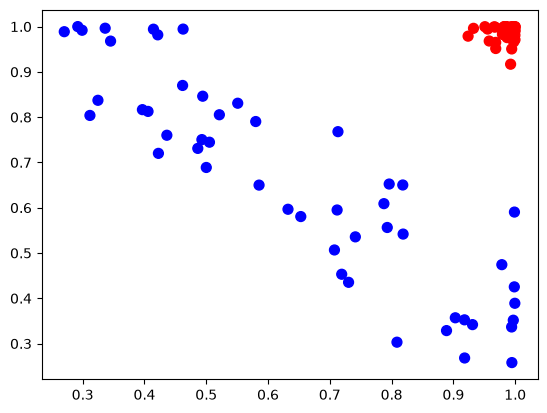

In [26]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')

As we can see instead of creating the 3d hyperplane with this simple sum trick we can create a linearly separable Data . So SVM is so good. 